In [1]:
import pandas as pd

# Load dataset
df = pd.read_csv('customer_churn_dataset.csv')

# look first 5 rows for understanding structure
df.head()

,CustomerID,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TechSupport,PaymentMethod,Churn
0,1,56,Female,62,470.48,Two year,Fiber optic,No,Net banking,0
1,2,69,Female,47,3916.24,Two year,DSL,Yes,Net banking,0
2,3,46,Male,23,444.16,Month-to-month,DSL,No,UPI,0
3,4,32,Male,38,825.22,Month-to-month,DSL,Yes,Credit card,1
4,5,60,Male,64,2571.41,Two year,NaN,Yes,Debit card,0


In [2]:
# chcek missing values and data types
print(df.info())
print("\nMissing Values:\n", df.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 10 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   CustomerID       100000 non-null  int64  
 1   Age              100000 non-null  int64  
 2   Gender           100000 non-null  object 
 3   Tenure           100000 non-null  int64  
 4   MonthlyCharges   100000 non-null  float64
 5   ContractType     100000 non-null  object 
 6   InternetService  66741 non-null   object 
 7   TechSupport      100000 non-null  object 
 8   PaymentMethod    100000 non-null  object 
 9   Churn            100000 non-null  int64  
dtypes: float64(1), int64(4), object(5)
memory usage: 7.6+ MB
None

Missing Values:
 CustomerID             0
Age                    0
Gender                 0
Tenure                 0
MonthlyCharges         0
ContractType           0
InternetService    33259
TechSupport            0
PaymentMethod          0
Churn           

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Fix the missing data
df['InternetService'] = df['InternetService'].fillna('No Internet')
print("Missing Values after fix:\n", df.isnull().sum())
print("-" * 30)

Missing Values after fix:
 CustomerID         0
Age                0
Gender             0
Tenure             0
MonthlyCharges     0
ContractType       0
InternetService    0
TechSupport        0
PaymentMethod      0
Churn              0
dtype: int64
------------------------------


C:\Users\vivek\AppData\Local\Temp\ipykernel_16884\1682033085.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')


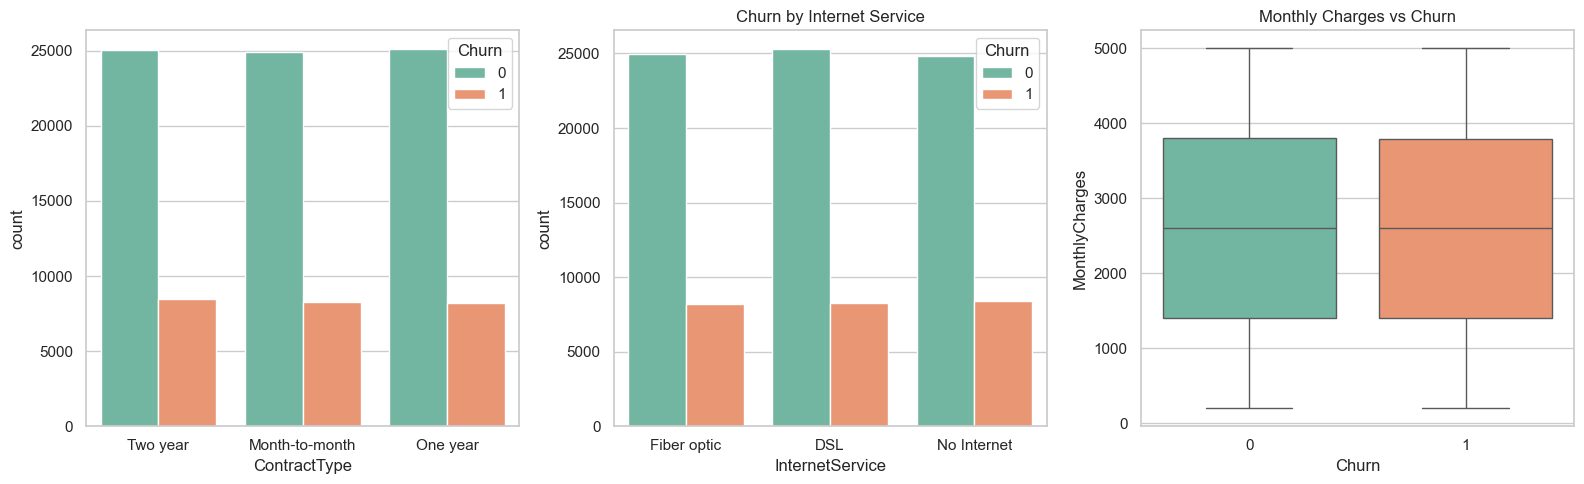

In [12]:
# Setup the Visualization style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(16, 5))

# Chart 1: Churn by Contract Type
plt.subplot(1, 3, 1)
sns.countplot(data=df, x='ContractType', hue='Churn', palette='Set2')

# Chart 2: Churn by Internet Servie
plt.subplot(1, 3, 2)
sns.countplot(data=df, x='InternetService', hue='Churn', palette='Set2')
plt.title('Churn by Internet Service')

# Chart 3: Monthly Charges vs Churn
plt.subplot(1, 3, 3)
sns.boxplot(data=df, x='Churn', y='MonthlyCharges', palette='Set2')
plt.title('Monthly Charges vs Churn')

plt.tight_layout()
plt.show()

In [15]:
from sklearn.preprocessing import LabelEncoder

# Drop Customer ID, it doesn't help predict Churn
df_ml = df.drop('CustomerID', axis=1)

# Identify all columns that contain text('object')
text_columns = df_ml.select_dtypes(include=['object']).columns
print("Columns to Convert:", list(text_columns))

# LabelEncode use to convert text to numbers
le = LabelEncoder()
for col in text_columns:
    df_ml[col] = le.fit_transform(df_ml[col])

# View the new, fully numeric dataset
print("\nData after Encoding:")
df_ml.head()

Columns to Convert: ['Gender', 'ContractType', 'InternetService', 'TechSupport', 'PaymentMethod']

Data after Encoding:


,Age,Gender,Tenure,MonthlyCharges,ContractType,InternetService,TechSupport,PaymentMethod,Churn
0,56,0,62,470.48,2,1,0,2,0
1,69,0,47,3916.24,2,0,1,2,0
2,46,1,23,444.16,0,0,0,3,0
3,32,1,38,825.22,0,0,1,0,1
4,60,1,64,2571.41,2,2,1,1,0


In [16]:
from sklearn.model_selection import train_test_split as split_dataset
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Separate the Clues
clues = df_ml.drop('Churn', axis=1) 
answers = df_ml['Churn']            

# Split the data
clues_build, clues_eval, answers_build, answers_eval = split_dataset(clues, answers, test_size=0.20, random_state=42)

print(f"Data used to build the models: {clues_build.shape[0]} customers")
print(f"Data used to evaluate the models: {clues_eval.shape[0]} customers\n")

# Initialize the Models
log_model = LogisticRegression(max_iter=1000)
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)

# Build the models
print("Building Logistic Regression model...")
log_model.fit(clues_build, answers_build)

print("Building Random Forest model...")
rf_model.fit(clues_build, answers_build)
print("Models successfully built!")

log_predictions = log_model.predict(clues_eval)
rf_predictions = rf_model.predict(clues_eval)

Data used to build the models: 80000 customers
Data used to evaluate the models: 20000 customers

Building Logistic Regression model...
Building Random Forest model...
Models successfully built!


In [19]:
from sklearn.metrics import accuracy_score, recall_score, roc_auc_score

def evaluate_model(model_name, actual_answers, predictions):
    acc = accuracy_score(actual_answers, predictions)
    rec = recall_score(actual_answers, predictions)
    auc = roc_auc_score(actual_answers, predictions)

    print(f"--- {model_name} Performance --")
    print(f"Accuracy: {acc:.4f} ({(acc*100):.1f}%)")
    print(f"Recall:  {rec:.4f} ({rec:.4f} ({(rec*100):.1f}%)")
    print(f"ROC-AUC: {auc:.4f}\n")

evaluate_model("Logistic Regression", answers_eval, log_predictions)
evaluate_model("Random Forest", answers_eval, rf_predictions)

print("Project 1 Code Successfully Completed!")

--- Logistic Regression Performance --
Accuracy: 0.7524 (75.2%)
Recall:  0.0000 (0.0000 (0.0%)
ROC-AUC: 0.5000

--- Random Forest Performance --
Accuracy: 0.7353 (73.5%)
Recall:  0.0434 (0.0434 (4.3%)
ROC-AUC: 0.5032

Project 1 Code Successfully Completed!


In [28]:
from imblearn.over_sampling import SMOTE

print("Applying SMOTE to balance the data...")
# Apply SMOTE
smote = SMOTE(random_state=42)
clues_build_smote, answers_build_smote = smote.fit_resample(clues_build, answers_build)

# Re-train the models on the BALANCED data
print("Re-building models with balanced data...")
log_model_smote = LogisticRegression(max_iter=1000)
log_model_smote.fit(clues_build_smote, answers_build_smote)

rf_model_smote = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model_smote.fit(clues_build_smote, answers_build_smote)

# Make new predictions
log_predictions_smote = log_model_smote.predict(clues_eval)
rf_predictions_smote = rf_model_smote.predict(clues_eval)

print("\n--- RESULTS AFTER FIXING THE DATA ---")
evaluate_model("Logistic Regression (with SMOTE)", answers_eval, log_predictions_smote)
evaluate_model("Random Forest (with SMOTE)", answers_eval, rf_predictions_smote)

Applying SMOTE to balance the data...
Re-building models with balanced data...

--- RESULTS AFTER FIXING THE DATA ---
--- Logistic Regression (with SMOTE) Performance --
Accuracy: 0.5573 (55.7%)
Recall:  0.3876 (0.3876 (38.8%)
ROC-AUC: 0.5004

--- Random Forest (with SMOTE) Performance --
Accuracy: 0.5978 (59.8%)
Recall:  0.2993 (0.2993 (29.9%)
ROC-AUC: 0.4976

